<a href="https://colab.research.google.com/github/chipojaya1/myNEBDHub/blob/main/Nutrition_and_Obesity_in_Latin_America_DSP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 align="center">
    NSDC Data Science Projects
</h1>
  
<h2 align="center">
    Project: Nutrition and Obesity in Latin America
</h2>

<h3 align="center">
    Name: Chipo Jaya
</h3>




---



### **Please read before you begin your project**

**Instructions: Google Colab Notebooks:**

Google Colab is a free cloud service. It is a hosted Jupyter notebook service that requires no setup to use, while providing free access to computing resources. We will be using Google Colab for this project.

Certain parts of this project will be completed individually, while other parts are encouraged to be completed with the rest of your team. In order to work within the Google Colab Notebook, **please start by clicking on "File" and then "Save a copy in Drive."** This will save a copy of the notebook in your personal Google Drive. Each member of your team should work on their personal copy.

Please rename the file to "TITLE - Your Full Name." Once this project is completed, you will be prompted to share your file with the National Student Data Corps (NSDC) Project Leaders.

You can now start working on the project. :)

We'll be using Google Colab for this assignment. This is a Python Notebook environment built by Google that's free for everyone and comes with a nice UI out of the box. For a comprehensive guide, see Colab's official guide [here](https://colab.research.google.com/github/prites18/NoteNote/blob/master/Welcome_To_Colaboratory.ipynb).

Colab QuickStart:
- Notebooks are made up of cells, cells can be either text or code cells. Click the +code or +text button at the top to create a new cell
- Text cells use a format called [Markdown](https://www.markdownguide.org/getting-started/). Cheatsheet is available [here](https://www.markdownguide.org/cheat-sheet/)
- Python code is run/executed in code cells. You can click the play button at the top left of a code block (sometimes hidden in the square brackets) to run the code in that cell. You can also hit shift+enter to run the cell that is currently selected. There is no concurrency since cells run one at a time but you can queue up multiple cells
- Each cell will run code individually but memory is shared across a notebook Runtime. You can think of a Runtime as a code session where everything you create and execute is temporarily stored. This means variables and functions are available between cells if you execute one cell before the other (physical ordering of cells does not matter). This also means that if you delete or change the name of something and re-execute the cell, the old data might still exist in the background. If things aren't making sense, you can always click Runtime -> restart runtime to start over.
- Runtimes will persist for a short period of time so you are safe if you lose connection or refresh the page but Google will shutdown a runtime after enough time has past. Everything that was printed out will remain on the page even if the runtime is disconnected
- Google's Runtimes come preinstalled with all the core python libraries (math, rand, time, etc) as well as common data analysis libraries (numpy, pandas, scikitlearn, matplotlib). Simply run `import numpy as np` in a code cell to make it available

# **Introduction**

---
Obesity is a growing public health challenge across Latin America, where rapid urbanization, changes in transportation, increased screen time, and shifting dietary patterns have contributed to rising rates of overweight and obesity. Countries in Latin America face a dual burden of malnutrition and obesity, making it especially important to understand how everyday lifestyle behaviors influence health outcomes. Obesity is closely linked to chronic conditions such as cardiovascular disease, diabetes, and reduced quality of life, making it a critical area of study for both researchers and policymakers.

This project uses real data from the **Who Global Health Observatory (GHO)** to explore:

- How obesity rates have changed over time across Latin America
- Which countries carry the highest burden
- Whether women and men are equally affected
- The relationship between child stunting and adult obesity

We can go beyond headlines and quantify these trends by examining publicly available health data, which allows us to compare other nations and determine where health interventions are most necessary.


# **References:**
[1] Popkin, B. M., & Reardon, T. (2018). Obesity and the food system transformation in Latin America. Obesity reviews : an official journal of the International Association for the Study of Obesity, 19(8), 1028–1064. https://doi.org/10.1111/obr.12694

[2] Banna J. (2019). Obesity Prevention in Children in Latin America Through Interventions Using Technology. American journal of lifestyle medicine, 13(2), 138–141. https://doi.org/10.1177/1559827618823320

# **Milestone 1: Data Collection**
---
**Step 1:**
Let's begin by importing all the Python libraries we need. Run this cell first.
| Library | Purpose |
|---|---|
| `requests` | Send HTTP requests to the WHO API |
| `pandas` | Load and manipulate tabular data |
| `matplotlib` | Create charts and graphs |
| `seaborn` | Higher-level, prettier statistical plots |

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Global plot styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (13, 6)
plt.rcParams["figure.dpi"] = 120

print ("Libraries loaded successfully! Proceed to step 2.")

Libraries loaded successfully! Proceed to step 2.


**Step 2:** Now it is time to understand our data source.

What is the WHO Global Health Observatory (GHO)?

The **World Health Organization (WHO)** maintains a free, public database called the [Global Health Observatory](https://www.who.int/data/gho). It contains thousands of health indicators for every country in the world, collected from national surveys, government ministries, and WHO estimates.

We access this data through the **GHO OData API**, a web interface that returns data in JSON format. No login, no download, no files (much simpler!). We send a web request and get data back.

**API base URL:** `https://ghoapi.azureedge.net/api/`

To fetch a specific indicator, you append its code:
```
https://ghoapi.azureedge.net/api/NCD_BMI_30A   ← adult obesity rates
```
Indicators we will use

| Code | Description |
|---|---|
| `NCD_BMI_30A` | Adult obesity prevalence — BMI ≥ 30 (age-standardized, %) |
| `NCD_BMI_25A` | Adult overweight prevalence — BMI ≥ 25 (age-standardized, %) |
| `NCD_BMI_PLUS2C` | Child/adolescent obesity — BMI > +2 SD (crude, %) |
| `NCD_BMI_MEAN` | Mean adult BMI (age-standardized, kg/m²) |
| `NUTSTUNTINGPREV` | Child stunting prevalence — height-for-age < -2 SD (%) |
| `NCD_BMI_18A` | Adult underweight prevalence — BMI < 18 (age-standardized, %) |


**Step 3:** We are fetching the data from the WHO API

The cell below loops through each indicator, calls the WHO API, filters to Latin American countries, and stacks everything into one dataframe.

In [ ]:
# Indicator codes and readable names
indicators = {
    "NCD_BMI_30A":    "Obesity_Adults",
    "NCD_BMI_25A":    "Overweight_Adults",
    "NCD_BMI_PLUS2C": "Obesity_Children",
    "NCD_BMI_MEAN":   "Mean_BMI",
    "NUTSTUNTINGPREV":"Stunting_Children",
    "NCD_BMI_18A":    "Underweight_Adults",
}

# Latin American country codes (ISO 3166-1 alpha-3)
latam_codes = [
    "MEX","ARG","PER","COL","BRA","CHL","BOL","ECU",
    "PRY","URY","GTM","HND","SLV","NIC","CRI",
    "PAN","CUB","DOM","HTI","VEN"
]

country_names = {
    "MEX":"Mexico",       "ARG":"Argentina",         "PER":"Peru",
    "COL":"Colombia",     "BRA":"Brazil",             "CHL":"Chile",
    "BOL":"Bolivia",      "ECU":"Ecuador",            "PRY":"Paraguay",
    "URY":"Uruguay",      "GTM":"Guatemala",          "HND":"Honduras",
    "SLV":"El Salvador",  "NIC":"Nicaragua",          "CRI":"Costa Rica",
    "PAN":"Panama",       "CUB":"Cuba",               "DOM":"Dominican Republic",
    "HTI":"Haiti",        "VEN":"Venezuela"
}

print("Fetching data from the WHO Global Health Observatory...\n")

dfs = []
for code, name in indicators.items():
    url = f"https://ghoapi.azureedge.net/api/{code}"
    response = requests.get(url)
    data = response.json().get("value", [])

    if not data:
        print(f"  No data returned for {code}")
        continue

    df = pd.DataFrame(data)
    df = df.drop(columns=["Value"], errors="ignore")

    if "SpatialDim" not in df.columns:
        print(f"  Unexpected API format for {code}")
        continue

    df = df[df["SpatialDim"].isin(latam_codes)].copy()
    df["Indicator"] = name
    dfs.append(df)
    print(f"  {name:<22} — {len(df):>4} rows loaded")

raw_data = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows in raw dataset: {raw_data.shape[0]:,}")


Fetching data from the WHO Global Health Observatory...

  Obesity_Adults         — 1980 rows loaded
  Overweight_Adults      — 1980 rows loaded
  Obesity_Children       — 5940 rows loaded
  Mean_BMI               — 2520 rows loaded
  Stunting_Children      — 1425 rows loaded
  Underweight_Adults     — 1980 rows loaded

Total rows in raw dataset: 15,825


# **Milestone 2: Data Preprocessing**
---


The raw API response contains many columns we don't need, cryptic column names, and columns stored as the wrong data type. In this step we **clean and reshape** the data into something ready for analysis.

**Step 1:** Select and rename columns
The raw dataframe has many columns. Here is what each one we keep actually means:

| Raw column | Renamed to | Meaning |
|---|---|---|
| `SpatialDim` | `Country` | 3-letter country code (e.g. "MEX") |
| `TimeDim` | `Year` | Year of measurement |
| `Dim1` | `Sex` | `SEX_BTSX` = both, `SEX_MLE` = male, `SEX_FMLE` = female |
| `NumericValue` | `Value` | The measured percentage or BMI value |
| `Low` | `Low` | Confidence interval lower bound |
| `High` | `High` | Confidence interval upper bound |
| `Indicator` | `Indicator` | Which health metric this row represents |

In [ ]:
clean_data = raw_data[[
    "SpatialDim",
    "TimeDim",
    "Dim1",
    "Dim2",
    "NumericValue",
    "Low",
    "High",
    "Indicator"
]].rename(columns={
    "SpatialDim":   "Country",
    "TimeDim":      "Year",
    "Dim1":         "Sex",
    "NumericValue": "Value"
})

# Add full country names
clean_data["CountryName"] = clean_data["Country"].map(country_names)

# Ensure Year and Value are stored as numbers, not strings
clean_data["Year"]  = pd.to_numeric(clean_data["Year"],  errors="coerce")
clean_data["Value"] = pd.to_numeric(clean_data["Value"], errors="coerce")

print("Shape:", clean_data.shape)
print("Year range:", clean_data["Year"].min(), "–", clean_data["Year"].max())
print("Sex categories:", list(clean_data["Sex"].unique()))

Shape: (15825, 9)
Year range: 1975 – 2024
Sex categories: ['SEX_BTSX', 'SEX_MLE', 'SEX_FMLE']


**Step 2:** Now it is time to fix `Obesity_Children` age groups


The `Obesity_Children` indicator (`NCD_BMI_PLUS2C`) is broken down by three age groups in the WHO data, stored in the `Dim2` column:

| `Dim2` value | Meaning |
|---|---|
| `AGEGROUP_YEARS05-09` | Children aged 5–9 only |
| `AGEGROUP_YEARS10-19` | Adolescents aged 10–19 only |
| `AGEGROUP_YEARS05-19` | Combined 5–19 years ← **this is the one we want** |

All other indicators have no `Dim2` breakdown, so we keep all their rows as-is. After the fix, we drop `Dim2` since it is no longer needed.

In [ ]:
# Check the age group codes present in Obesity_Children
print("Age groups in Obesity_Children:")
print(clean_data[clean_data["Indicator"] == "Obesity_Children"]["Dim2"].value_counts())

# For all other indicators, Dim2 should be None
print("\nDim2 values in other indicators:")
print(clean_data[clean_data["Indicator"] != "Obesity_Children"]["Dim2"].value_counts())

Age groups in Obesity_Children:
Dim2
AGEGROUP_YEARS10-19    1980
AGEGROUP_YEARS05-19    1980
AGEGROUP_YEARS05-09    1980
Name: count, dtype: int64

Dim2 values in other indicators:
Dim2
AGEGROUP_YEARS18-PLUS    8460
Name: count, dtype: int64


In [ ]:
# Keep only the combined 5–19 age group for Obesity_Children
# All other indicators are unaffected
mask_children = clean_data["Indicator"] == "Obesity_Children"
mask_combined = clean_data["Dim2"] == "AGEGROUP_YEARS05-19"

clean_data = clean_data[
    (~mask_children) | (mask_children & mask_combined)
].copy()

# Drop Dim2 (no longer needed)
clean_data = clean_data.drop(columns=["Dim2"])

print("Obesity_Children rows after fix:",
      len(clean_data[clean_data["Indicator"] == "Obesity_Children"]))
print("Other indicator rows (sample):",
      len(clean_data[clean_data["Indicator"] == "Obesity_Adults"]))


Obesity_Children rows after fix: 1980
Other indicator rows (sample): 1980


**Step 3:** Filter both sexes

Each indicator comes in three versions: male, female, and both sexes combined. For most of our analysis we use the combined category (`SEX_BTSX`). We keep the full dataset for the gender comparison chart in Milestone 5.

In [ ]:
# Main analysis dataset — both sexes combined
both_sexes = clean_data[clean_data["Sex"] == "SEX_BTSX"].copy()

print("Rows (both sexes):", len(both_sexes))
print("Countries:", both_sexes["CountryName"].nunique())
print("Indicators:", both_sexes["Indicator"].nunique())

Rows (both sexes): 3955
Countries: 20
Indicators: 6


# **Milestone 3: Data Cleaning**
---


Now it is time to fix actual problems in the dataset. This is different from preprocessing (which was about reshaping and renaming).  Data cleaning is about finding and handling **bad, missing, or duplicate data** before we analyse anything.

**Step 1:** Let's handle duplicates

In [ ]:
# Check for duplicate rows
duplicates = clean_data.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

# Drop them
clean_data = clean_data.drop_duplicates()
both_sexes = both_sexes.drop_duplicates()
print(f"Rows after removing duplicates: {len(clean_data)}")

Duplicate rows found: 0
Rows after removing duplicates: 11865


**Step 2:** Let's handle missing values in the `Value` column

Some rows exist in the dataset but have no numeric value recorded — the WHO may have a record for a country/year but no actual measurement. We need to drop these or they will cause errors in our charts.


In [ ]:
# How many rows are missing a Value?
missing_values = clean_data["Value"].isna().sum()
print(f"Rows with missing Value: {missing_values}")

# Which countries and indicators are most affected?
print("\nBreakdown by indicator:")
print(clean_data[clean_data["Value"].isna()]["Indicator"].value_counts())

Rows with missing Value: 0

Breakdown by indicator:
Series([], Name: count, dtype: int64)


In [ ]:
# Drop rows where Value is missing as we cannot plot or analyse them
clean_data = clean_data.dropna(subset=["Value"])
both_sexes = both_sexes.dropna(subset=["Value"])
print(f"Rows after dropping missing values: {len(clean_data)}")

Rows after dropping missing values: 11865


**Step 3:** Handling impossible values

Obesity prevalence is a percentage, so it must be between 0 and 100. Mean BMI must also be within a realistic human range. Any values outside these bounds are data errors.


In [ ]:
# Check for values outside the valid range (0–100 for percentages)
out_of_range = clean_data[
    (clean_data["Indicator"] != "Mean_BMI") &
    ((clean_data["Value"] < 0) | (clean_data["Value"] > 100))
]
print(f"Out-of-range percentage values: {len(out_of_range)}")

# Check Mean BMI is within a realistic range (15–50 kg/m²)
bad_bmi = clean_data[
    (clean_data["Indicator"] == "Mean_BMI") &
    ((clean_data["Value"] < 15) | (clean_data["Value"] > 50))
]
print(f"Out-of-range BMI values: {len(bad_bmi)}")

Out-of-range percentage values: 0
Out-of-range BMI values: 0


We see that there are not duplicates nor missing values. It is always good to check this. Even when we didn't find anything now, it is good practice to filter this for future projects.

**Step 4:** Now that we did some data cleaning, it is time to see our summary before delving deep into the exploratory data analysis (EDA).

In [ ]:
print("Clean dataset summary: ")
print(f"Total rows:    {len(clean_data):,}")
print(f"Countries:     {clean_data['CountryName'].nunique()}")
print(f"Indicators:    {clean_data['Indicator'].nunique()}")
print(f"Year range:    {int(clean_data['Year'].min())} – {int(clean_data['Year'].max())}")
print(f"Missing values remaining: {clean_data['Value'].isna().sum()}")

clean_data.head()

Clean dataset summary: 
Total rows:    11,865
Countries:     20
Indicators:    6
Year range:    1975 – 2024
Missing values remaining: 0


,Country,Year,Sex,Value,Low,High,Indicator,CountryName
0,HTI,2018,SEX_BTSX,9.645648,8.001596,11.533726,Obesity_Adults,Haiti
1,CUB,2019,SEX_BTSX,20.011504,18.030235,22.119252,Obesity_Adults,Cuba
2,BRA,1996,SEX_BTSX,10.664838,9.884284,11.470906,Obesity_Adults,Brazil
3,URY,2020,SEX_MLE,28.863022,23.000121,35.040638,Obesity_Adults,Uruguay
4,CHL,2012,SEX_MLE,24.432382,22.482100,26.403084,Obesity_Adults,Chile


# **Milestone 4: Exploratory Data Analysis (EDA)**
---


Before building any charts, we **get to know the data**. EDA helps us catch problems early and understand what we're working with. This is the shape of the data, what values look like, and where information is missing.

**Step 1:** Let's take a look. What does the data actually look like?

In [ ]:
# Preview the first 5 rows of the cleaned dataset
clean_data.head()

,Country,Year,Sex,Value,Low,High,Indicator,CountryName
0,HTI,2018,SEX_BTSX,9.645648,8.001596,11.533726,Obesity_Adults,Haiti
1,CUB,2019,SEX_BTSX,20.011504,18.030235,22.119252,Obesity_Adults,Cuba
2,BRA,1996,SEX_BTSX,10.664838,9.884284,11.470906,Obesity_Adults,Brazil
3,URY,2020,SEX_MLE,28.863022,23.000121,35.040638,Obesity_Adults,Uruguay
4,CHL,2012,SEX_MLE,24.432382,22.482100,26.403084,Obesity_Adults,Chile


**Step 2:** What is the range of values?
| Stat | What it tells you |
|---|---|
| `count` | How many rows have a non-missing value |
| `mean` | The average value across all indicators and countries |
| `min` / `max` | The lowest and highest values in the entire dataset |
| `25%` / `75%` | The middle range — half of all values fall between these two numbers |
| `std` | Standard deviation — how spread out the values are |


In [ ]:
# Summary statistics for the Value column
clean_data["Value"].describe().round(2)

,Value
count,11865.00
mean,21.04
std,17.17
min,0.44
25%,6.83
50%,18.75
75%,26.30
max,78.98


**Step 3:** How much data do we have?

In [ ]:
# How many unique years are in the dataset?
# Hint: use .nunique() on the Year column

### YOUR CODE HERE ###

# Hint: use .value_counts() on the Indicator column

### YOUR CODE HERE ###



**Step 4:** Let's take a initial look at our data. How complete is our data?  

This heatmap shows how many years of data each country has for each indicator. Dark green = many years of data. Light = few or none.

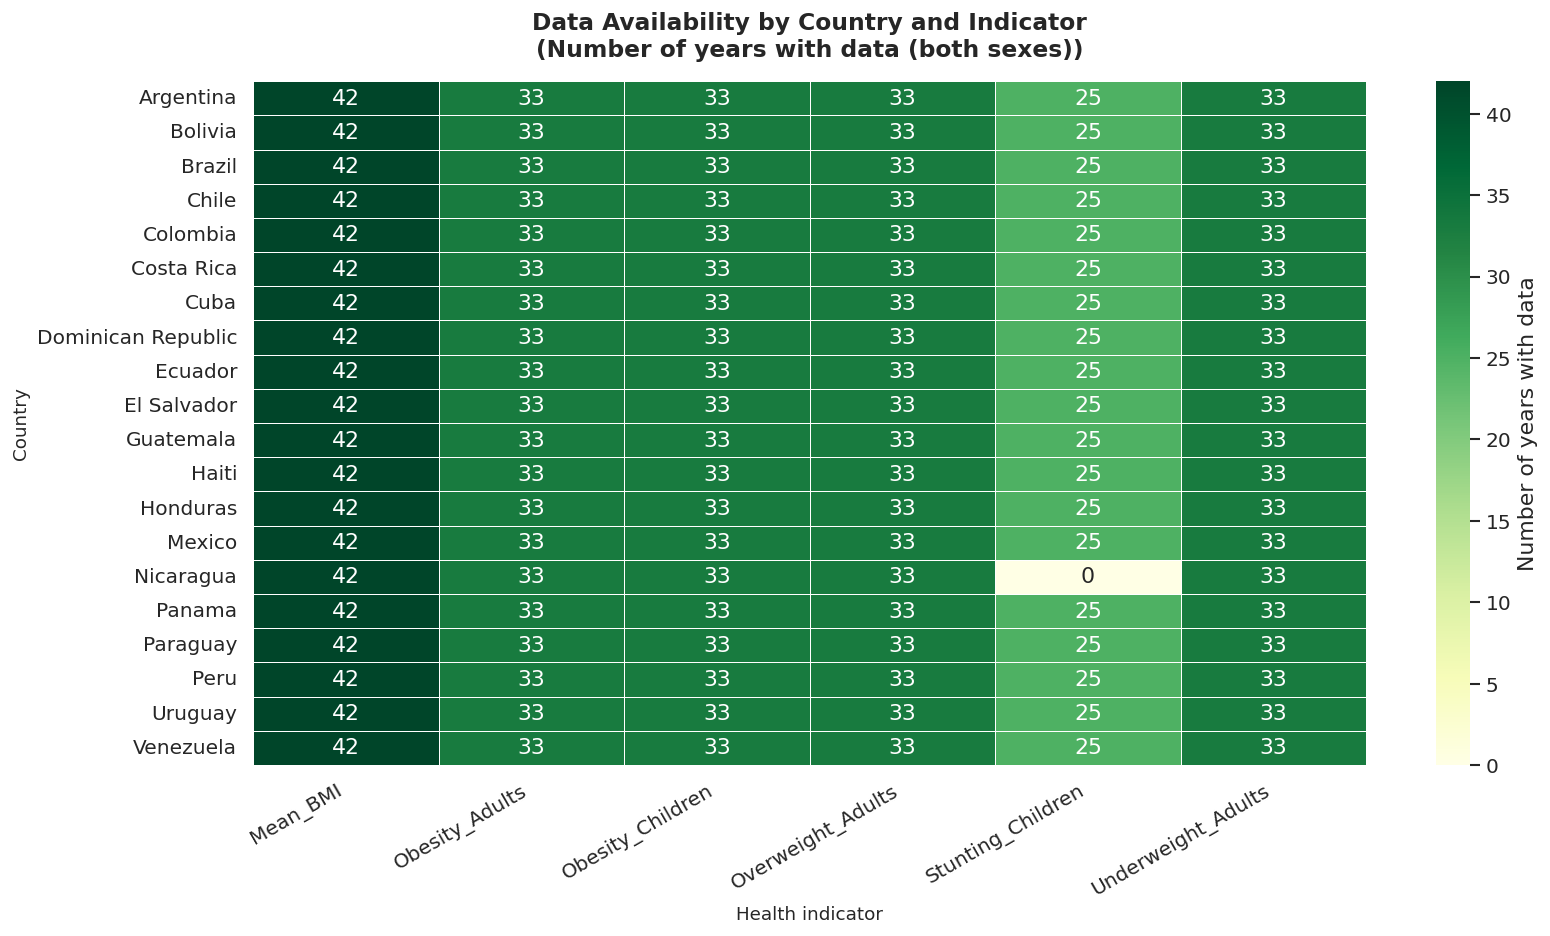

In [ ]:
# Visualize data availability across countries and indicators
# (how many years of data does each country have per indicator?)

availability = (
    both_sexes
    .groupby(["CountryName", "Indicator"])["Value"]
    .count()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(availability, cmap="YlGn", linewidths=0.5,
            annot=True, fmt="d",
            cbar_kws={"label": "Number of years with data"},
            ax=ax)
ax.set_title("Data Availability by Country and Indicator\n"
             "(Number of years with data (both sexes))",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Health indicator", fontsize=11)
ax.set_ylabel("Country", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Question:** Every country shows the exact same number of data points for each indicator. Why might that be? Does that mean the WHO actually surveyed every country every year, or could something else explain it?

**Ans:**

# **Milestone 5: Data visualization**
---

Now for the core of the project. We build **six charts** that each tell a different part of the obesity story in Latin America. We will start with line charts, followed by bar charts, grouped bar charts, scatterplots and heatmaps. We will have an optional challenge: creating our own poster!

**Step 1:** Create a line chart for adult obesity rates over time of Mexico, Argentina, Peru, Colombia, Brazil and Chile.

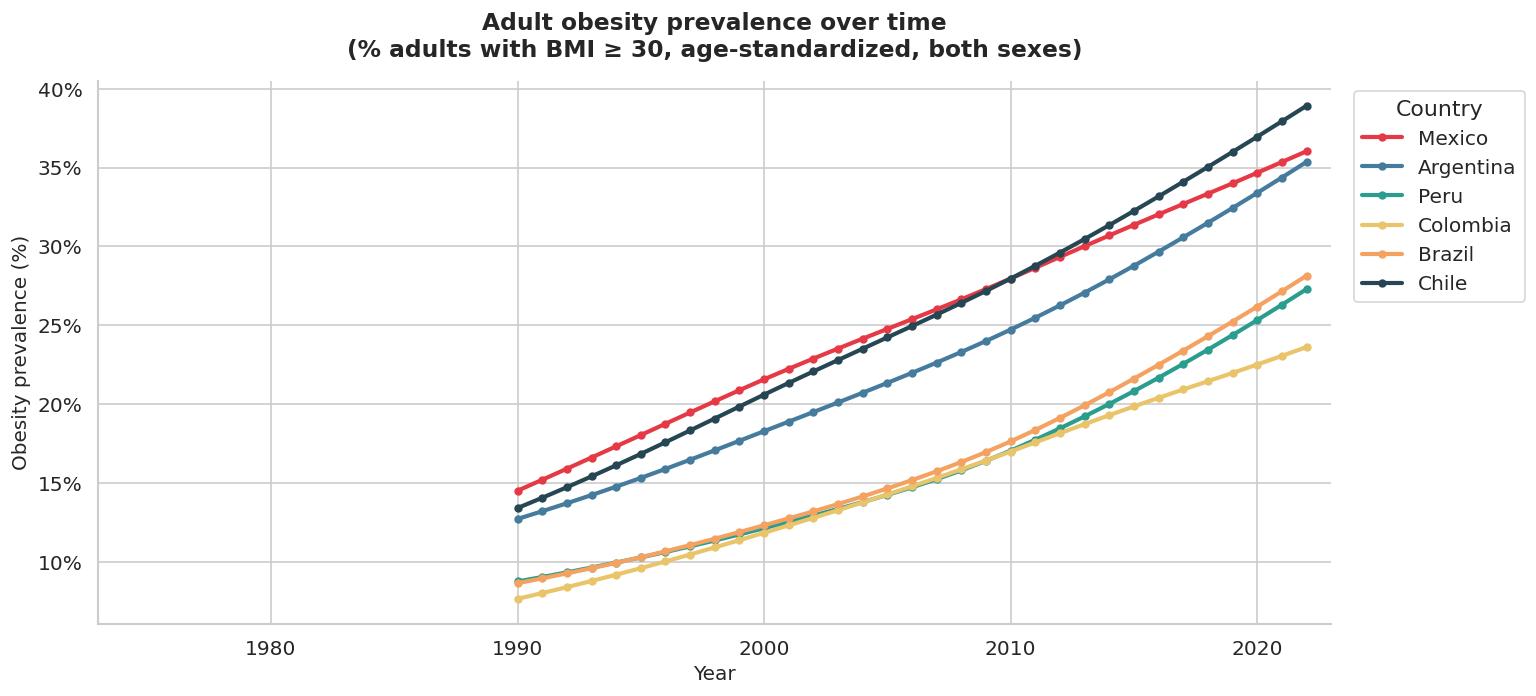

In [ ]:
focus_countries = ["MEX", "ARG", "PER", "COL", "BRA", "CHL"]

obesity_trend = both_sexes[
    (both_sexes["Indicator"] == "Obesity_Adults") &
    (both_sexes["Country"].isin(focus_countries))
].sort_values("Year")

colors = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261", "#264653"]

fig, ax = plt.subplots()

for i, code in enumerate(focus_countries):
    data = obesity_trend[obesity_trend["Country"] == code]
    ax.plot(data["Year"], data["Value"],
            marker="o", linewidth=2.5, markersize=4,
            label=country_names[code], color=colors[i])

ax.set_title("Adult obesity prevalence over time\n"
             "(% adults with BMI ≥ 30, age-standardized, both sexes)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Obesity prevalence (%)", fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(title="Country", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xlim(1973, 2023)
sns.despine()
plt.tight_layout()
plt.show()


**Question 2:** Describe the overall trend. Has obesity been rising, falling, or staying flat? Is the rate of increase accelerating or slowing down? Which country shows the steepest rise?

**Ans:**

In [ ]:
# TODO:  Modify `focus_countries` to include `"BOL"` and `"URY"` instead of `"BRA"` and `"CHL"`. What do you notice?

### YOUR CODE HERE ####


**Step 2:** Create a bar chart comparing countries by most recent year

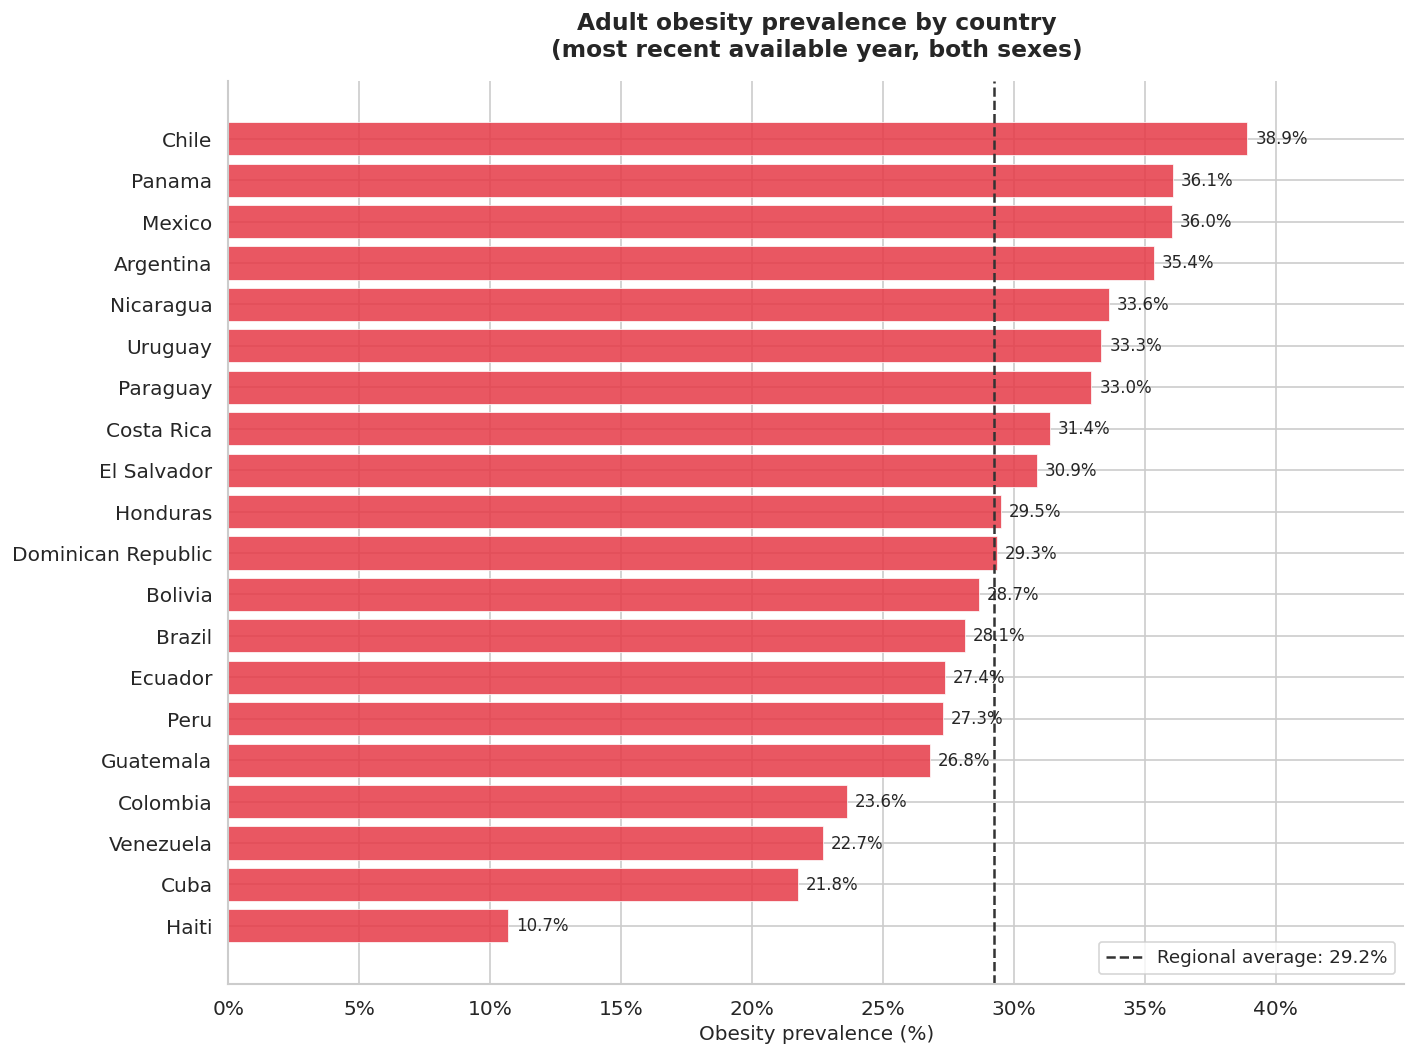

In [ ]:
latest_obesity = (
    both_sexes[both_sexes["Indicator"] == "Obesity_Adults"]
    .sort_values("Year")
    .groupby("Country").last().reset_index()
)
latest_obesity["CountryName"] = latest_obesity["Country"].map(country_names)
latest_obesity = latest_obesity.sort_values("Value", ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))

bars = ax.barh(latest_obesity["CountryName"], latest_obesity["Value"],
               color="#e63946", alpha=0.85, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, latest_obesity["Value"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10)

avg = latest_obesity["Value"].mean()
ax.axvline(avg, color="#333333", linestyle="--", linewidth=1.5,
           label=f"Regional average: {avg:.1f}%")

ax.set_title("Adult obesity prevalence by country\n"
             "(most recent available year, both sexes)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Obesity prevalence (%)", fontsize=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(0, latest_obesity["Value"].max() + 6)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# TODO:  Modify the cell above to show `"Overweight_Adults"` instead of `"Obesity_Adults"`. Does the country ranking change?

### YOUR CODE HERE ####

**Step 3:** Gender gap in obesity

Are women and men equally affected? This **grouped bar chart** puts male and female rates side by side, sorted by the size of the gender gap.

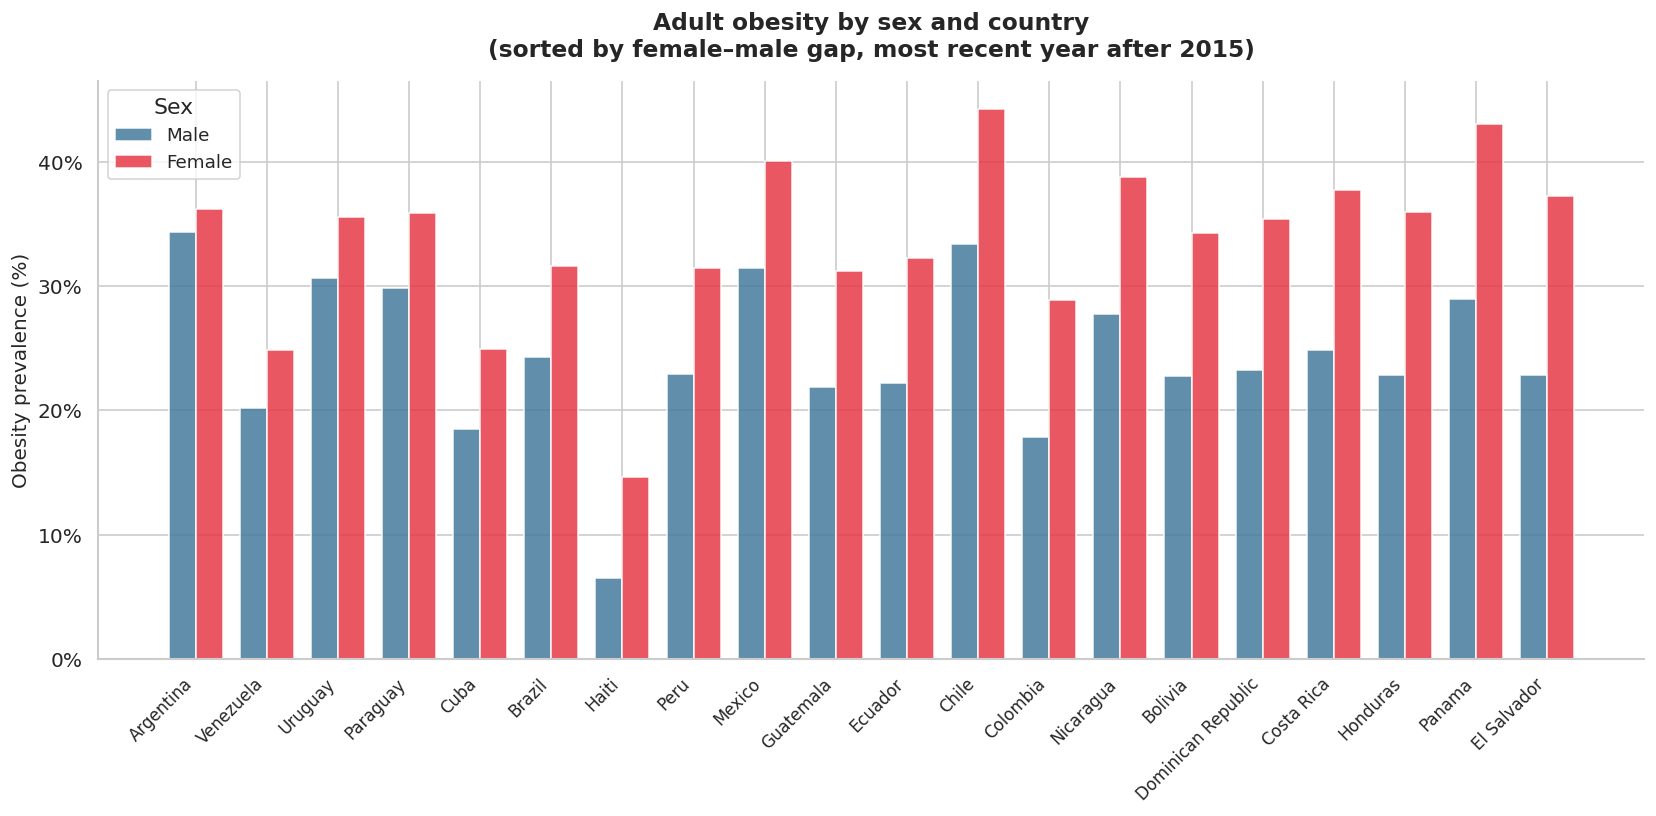

In [ ]:
gender_data = (
    clean_data[
        (clean_data["Indicator"] == "Obesity_Adults") &
        (clean_data["Sex"].isin(["SEX_MLE", "SEX_FMLE"])) &
        (clean_data["Year"] >= 2015)
    ]
    .sort_values("Year")
    .groupby(["Country", "Sex"]).last().reset_index()
)
gender_data["CountryName"] = gender_data["Country"].map(country_names)

gender_pivot = (
    gender_data
    .pivot(index="CountryName", columns="Sex", values="Value")
    .dropna()
    .rename(columns={"SEX_MLE": "Male", "SEX_FMLE": "Female"})
)
gender_pivot["gap"] = gender_pivot["Female"] - gender_pivot["Male"]
gender_pivot = gender_pivot.sort_values("gap")

x = range(len(gender_pivot))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar([i - width / 2 for i in x], gender_pivot["Male"],
       width, label="Male",   color="#457b9d", alpha=0.85)
ax.bar([i + width / 2 for i in x], gender_pivot["Female"],
       width, label="Female", color="#e63946", alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(gender_pivot.index, rotation=45, ha="right", fontsize=10)
ax.set_title("Adult obesity by sex and country\n"
             "(sorted by female–male gap, most recent year after 2015)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Obesity prevalence (%)", fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(title="Sex", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

**Question**: In most Latin American countries, is obesity higher in women or men? In which country is the gender gap the largest? What social or cultural factors might explain this?

**Ans:**

**Step 4:** The dual burden of malnutrition

One of the most striking features of Latin American nutrition is the **dual burden**: the same country can have high rates of child stunting (undernutrition) AND high rates of adult obesity at the same time.

A **scatter plot** shows the relationship between two continuous variables (one country per dot).

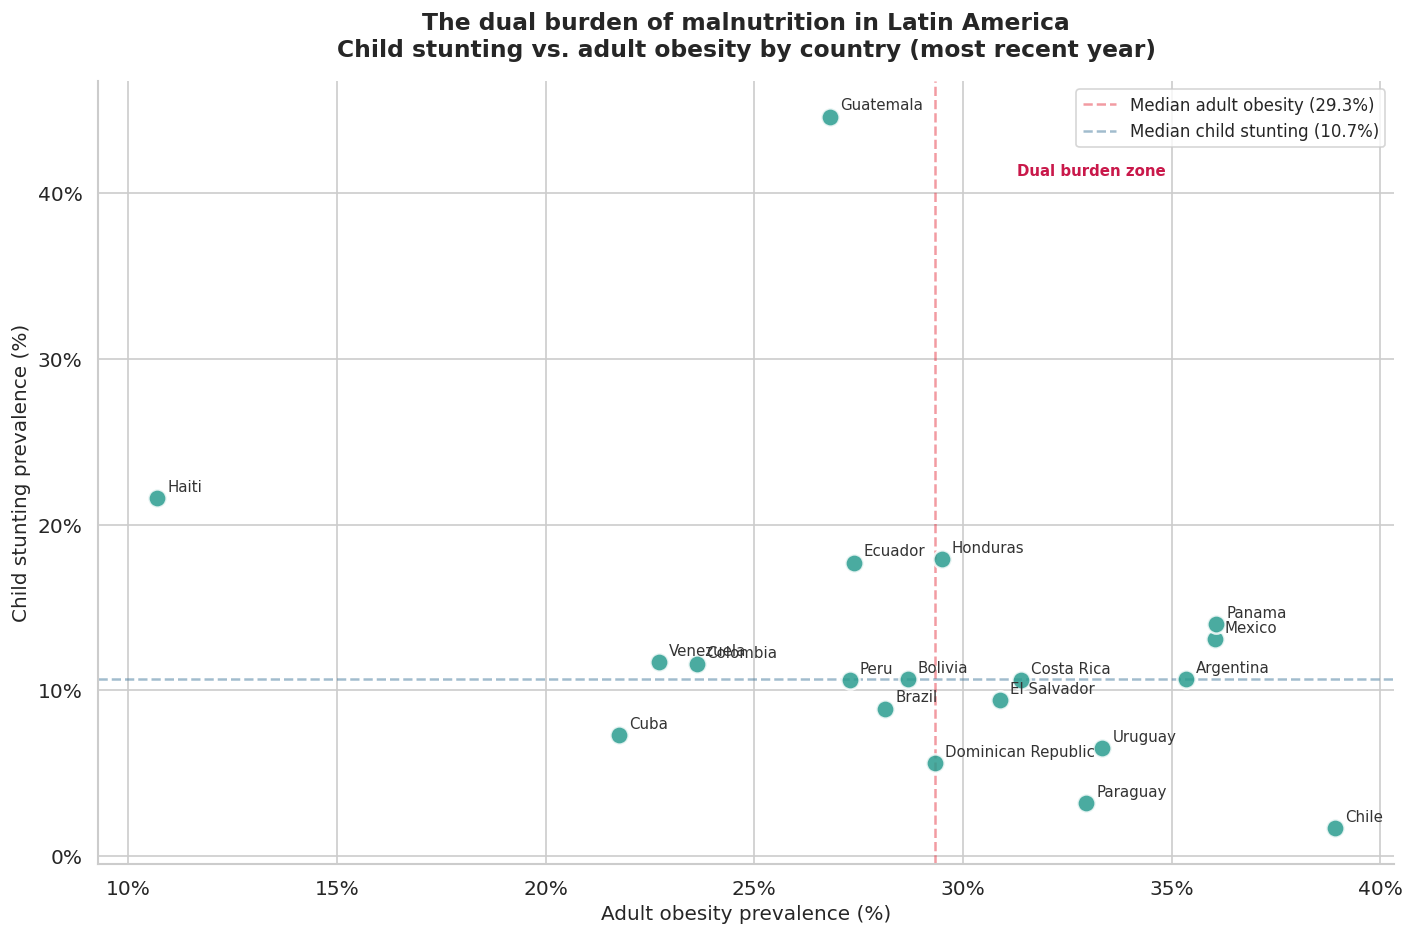

In [ ]:
obesity_latest = (
    both_sexes[both_sexes["Indicator"] == "Obesity_Adults"]
    .sort_values("Year").groupby("Country").last().reset_index()
    [["Country", "Value"]].rename(columns={"Value": "Obesity_Adults"})
)
stunting_latest = (
    both_sexes[both_sexes["Indicator"] == "Stunting_Children"]
    .sort_values("Year").groupby("Country").last().reset_index()
    [["Country", "Value"]].rename(columns={"Value": "Stunting_Children"})
)

dual = obesity_latest.merge(stunting_latest, on="Country").dropna()
dual["CountryName"] = dual["Country"].map(country_names)

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(dual["Obesity_Adults"], dual["Stunting_Children"],
           s=120, color="#2a9d8f", alpha=0.85,
           edgecolors="white", linewidths=1.5, zorder=3)

for _, row in dual.iterrows():
    ax.annotate(row["CountryName"],
                xy=(row["Obesity_Adults"], row["Stunting_Children"]),
                xytext=(6, 4), textcoords="offset points",
                fontsize=9, color="#333333")

med_ob = dual["Obesity_Adults"].median()
med_st = dual["Stunting_Children"].median()
ax.axvline(med_ob, color="#e63946", linestyle="--", alpha=0.5,
           label=f"Median adult obesity ({med_ob:.1f}%)")
ax.axhline(med_st, color="#457b9d", linestyle="--", alpha=0.5,
           label=f"Median child stunting ({med_st:.1f}%)")

ax.text(dual["Obesity_Adults"].max() * 0.85, dual["Stunting_Children"].max() * 0.92,
        "Dual burden zone", fontsize=9, color="#c9184a",
        ha="center", fontweight="bold")

ax.set_xlabel("Adult obesity prevalence (%)", fontsize=12)
ax.set_ylabel("Child stunting prevalence (%)", fontsize=12)
ax.set_title("The dual burden of malnutrition in Latin America\n"
             "Child stunting vs. adult obesity by country (most recent year)",
             fontsize=14, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


**Step 5:** Child obesity vs. child stunting

The dual burden chart you just saw compared **adult obesity** to **child stunting**, mixing two different age groups. Now build a cleaner version using **child indicators only**: `Obesity_Children` on the X axis and `Stunting_Children` on the Y axis.

This tells a more focused story: are the same countries failing children on both ends of the nutrition spectrum at the same time?

Fill in every `### TODO ###` to make it run.

In [ ]:
# Step 1: get most recent Obesity_Children value per country
child_obesity = (
    both_sexes[both_sexes["Indicator"] == ### TODO ###]
    .sort_values("Year").groupby("Country").last().reset_index()
    [["Country", "Value"]].rename(columns={"Value": ### TODO ###})
)

# Step 2: get most recent Stunting_Children value per country
child_stunting = (
    both_sexes[both_sexes["Indicator"] == ### TODO ###]
    .sort_values("Year").groupby("Country").last().reset_index()
    [["Country", "Value"]].rename(columns={"Value": ### TODO ###})
)

# Step 3: merge
child_dual = child_obesity.merge(child_stunting, on="Country").dropna()
child_dual["CountryName"] = child_dual["Country"].map(country_names)

# Step 4: scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    child_dual[### TODO: x axis column ###],
    child_dual[### TODO: y axis column ###],
    s=120, color=### TODO: pick a hex color ###,
    alpha=0.85, edgecolors="white", linewidths=1.5, zorder=3
)

for _, row in child_dual.iterrows():
    ax.annotate(row["CountryName"],
                xy=(row[### TODO ###], row[### TODO ###]),
                xytext=(6, 4), textcoords="offset points",
                fontsize=9, color="#333333")

med_x = child_dual[### TODO ###].median()
med_y = child_dual[### TODO ###].median()
ax.axvline(med_x, color="#e63946", linestyle="--", alpha=0.5,
           label=f"Median child obesity ({med_x:.1f}%)")
ax.axhline(med_y, color="#457b9d", linestyle="--", alpha=0.5,
           label=f"Median child stunting ({med_y:.1f}%)")

ax.set_xlabel(### TODO: x axis label ###, fontsize=12)
ax.set_ylabel(### TODO: y axis label ###, fontsize=12)
ax.set_title(### TODO: chart title ###, fontsize=14, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

SyntaxError: closing parenthesis ')' does not match opening parenthesis '{' on line 5 (2401056306.py, line 6)

**Question:** Are the countries with the highest child obesity also the ones with the highest child stunting? Or do they seem to be different countries? What does that tell you?

**Ans:**

**Step 6:** Comparing adult obesity vs. adult underweight

Now do the same but for **adults only**: `Obesity_Adults` on the X axis and `Underweight_Adults` on the Y axis.

This shows whether a country has adults on both extremes of BMI at the same time — some people obese, others underweight, which points to deep inequality in food access within the same population.

Use the child chart above as your reference.

In [ ]:
# Your code here

**Question:** Compare this chart to the child version in 4.5. Does the pattern look similar or different? Which countries show the starkest adult-level dual burden?

**Ans:**


**Step 7:** Comparing the mean BMI over time across regions

A **heatmap** encodes a numeric value as color. Here we show how mean adult BMI has changed across all 20 countries since 1990. This gives a "big picture" view of the entire region in one chart.


In [ ]:
# Filter to every 5 years for a cleaner heatmap
bmi_data = both_sexes[
    (both_sexes["Indicator"] == "Mean_BMI") &
    (both_sexes["Year"] % 5 == 0) &
    (both_sexes["Year"] >= 1990)
].copy()

bmi_pivot = bmi_data.pivot_table(
    index="CountryName", columns="Year", values="Value"
)
bmi_pivot = bmi_pivot.sort_values(bmi_pivot.columns[-1], ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(bmi_pivot, cmap="YlOrRd", annot=True, fmt=".1f",
            linewidths=0.5,
            cbar_kws={"label": "Mean BMI (kg/m²)"},
            ax=ax)
ax.set_title("Mean adult BMI across Latin America over time\n"
             "(age-standardized, both sexes(every 5 years))",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# TODO:  Create a similar heatmap for `"Obesity_Adults"` instead of `"Mean_BMI"`. Does the country ranking change?

### YOUR CODE HERE ####

In [ ]:
# TODO:  Create a similar heatmap for `"Obesity_Children"` instead of `"Obesity_Adults"`. Does the country ranking change?

### YOUR CODE HERE ####

**Step 8:** Create a data story card

You have spent this entire project looking at 20 countries at once. Now zoom in. Pick **one country** that surprised you, challenged your assumptions, or that you want to know more about.

In the markdown cell below, fill in your data story card. Replace every *italic placeholder* with your own words and real numbers from your charts.

### My Country: *[Country name here]*

**Why I chose this country:**
*[One sentence. What caught your attention about this country in the data?]*

---

#### What the data shows

| | |
|---|---|
| Adult obesity rate | *[X]%* |
| Trend since 1990 | *[rising / stable / accelerating]* |
| Gender gap | *[women higher / men higher / roughly equal]* |
| Child stunting rate | *[X]%* |
| Dual burden? | *[yes / no / borderline]* |

---

#### My three key findings

1. *[Finding with a specific number from your charts]*
2. *[Finding with a specific number from your charts]*
3. *[Something that surprised you]*

#### My policy recommendation

*[If you were advising this country's health minister, what is the ONE thing you would recommend based on what you found? Be specific.]*

# **Optional Challenge:**
Want to take your data story card further? Turn it into a **visual poster** that you could present to your class, your community, or a real health organization.

# What your poster should include

- **A title** that tells the story, not just describes the data
  *(e.g. "Mexico's Silent Crisis: Four Decades of Rising Obesity," not just "Obesity in Mexico")*

- **2–3 charts** from this notebook that best support your story
  *(export them by right-clicking the chart output in Colab and saving as image)*

- **Your key findings** in plain language. No jargon, written for a general audience

- **One policy recommendation** backed by your data

- **Your data source**


## NSDC poster resources

Check the NSDC project portal for past examples from previous Data Science Projects (DSP).

<h3 align = 'center' >
Thank you for completing the project!
</h3>

Please submit all materials to the NSDC HQ team at nsdc@columbia.edu
 in order to receive a virtual certificate of completion. Do reach out to us if you have any questions or concerns. We are here to help you learn and grow.